# 🔬 Retinal Blood Vessel Segmentation
### CNN-Based Segmentation of Fundus Images
**Models:** U-Net · Attention U-Net · Res-UNet · U-Net++ · DeepLabV3+ · FPN  
**Dataset:** DRIVE-style, 45 images (15 cases × 3 types)

## Section 0 — Setup & Imports

In [1]:
import subprocess, sys
pkgs = ["torch","torchvision","albumentations","opencv-python-headless",
        "scikit-learn","matplotlib","tqdm","scipy","pillow"]
subprocess.check_call([sys.executable,"-m","pip","install","-q","--upgrade"]+pkgs)
print("✅ All packages installed")

✅ All packages installed


In [2]:
import os, random, warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix
from scipy import ndimage
from tqdm import tqdm
import glob

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
print(f"[DEVICE] {DEVICE}  |  AMP enabled: {USE_AMP}")
print(f"[SEED]   42")

C:\Users\hashm\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[DEVICE] cpu  |  AMP enabled: False
[SEED]   42


## Section 1 — Configuration

In [3]:
# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE    = 256
BATCH_SIZE  = 4
LR          = 1e-4
WEIGHT_DECAY= 1e-5
EPOCHS      = 50
EARLY_STOP  = 10
SEED        = 42

# ── Paths (run notebook from inside 'acv project/' folder) ──
BASE_DIR    = os.getcwd()
IMG_DIR     = os.path.join(BASE_DIR, 'all', 'images')
MASK_DIR    = os.path.join(BASE_DIR, 'all', 'manual1')   # GT vessel labels
FOV_DIR     = os.path.join(BASE_DIR, 'all', 'mask')      # FOV region masks
CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Verify paths
for d, name in [(IMG_DIR,'images'),(MASK_DIR,'manual1'),(FOV_DIR,'mask')]:
    count = len(os.listdir(d)) if os.path.exists(d) else 0
    print(f"[CONFIG] {name:10s}: {count} files  →  {d}")
print(f"[CONFIG] Image size   : {IMG_SIZE}x{IMG_SIZE}")
print(f"[CONFIG] Batch size   : {BATCH_SIZE}")
print(f"[CONFIG] LR / Epochs  : {LR} / {EPOCHS}")

[CONFIG] images    : 45 files  →  c:\ACV\acv project\all\images
[CONFIG] manual1   : 45 files  →  c:\ACV\acv project\all\manual1
[CONFIG] mask      : 45 files  →  c:\ACV\acv project\all\mask
[CONFIG] Image size   : 256x256
[CONFIG] Batch size   : 4
[CONFIG] LR / Epochs  : 0.0001 / 50


## Section 2 — Utilities

In [4]:
# ── CLAHE ──────────────────────────────────────────────────
def apply_clahe(img_rgb):
    """Apply CLAHE via LAB color space to enhance vessel contrast."""
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

# ── Class imbalance ────────────────────────────────────────
def print_class_imbalance(dataset):
    total_pos = total_pix = 0
    for _, mask in dataset:
        total_pos += mask.sum().item()
        total_pix += mask.numel()
    pct = 100 * total_pos / total_pix
    print(f"[CLASS IMBALANCE] Vessel: {pct:.2f}%  Background: {100-pct:.2f}%")
    return pct

# ── Morphological post-processing ─────────────────────────
def morph_postprocess(pred_np):
    """Thin-vessel refinement: close gaps, remove noise."""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    closed = cv2.morphologyEx(pred_np, cv2.MORPH_CLOSE, kernel, iterations=1)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel, iterations=1)
    return opened

# ── Test-Time Augmentation ─────────────────────────────────
def tta_predict(model, img_tensor, device):
    """Average predictions over flips and 90-degree rotations."""
    model.eval()
    preds = []
    with torch.no_grad():
        for flip in [None, 'h', 'v']:
            for rot_k in [0, 1, 2, 3]:
                x = img_tensor.clone()
                if flip == 'h': x = torch.flip(x, [3])
                if flip == 'v': x = torch.flip(x, [2])
                x = torch.rot90(x, k=rot_k, dims=[2,3])
                p = model(x.to(device))
                p = torch.rot90(p, k=-rot_k, dims=[2,3])
                if flip == 'h': p = torch.flip(p, [3])
                if flip == 'v': p = torch.flip(p, [2])
                preds.append(p.cpu())
    return torch.stack(preds).mean(0)

# ── Ensemble ───────────────────────────────────────────────
def ensemble_predict(models, img_tensor, device):
    preds = [tta_predict(m, img_tensor, device) for m in models]
    return torch.stack(preds).mean(0)

# ── Visualization ──────────────────────────────────────────
def visualize_predictions(images, gt_masks, pred_masks, n=5, save_path=None):
    n = min(n, len(images))
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    titles = ['Original', 'Ground Truth', 'Prediction', 'Overlay']
    if n == 1: axes = [axes]
    for i in range(n):
        img  = images[i].permute(1,2,0).cpu().numpy()
        img  = (img - img.min()) / (img.max() - img.min() + 1e-8)
        gt   = gt_masks[i].squeeze().cpu().numpy()
        pred = pred_masks[i].squeeze().cpu().numpy()
        pred_bin = (pred > 0.5).astype(np.float32)
        overlay = img.copy()
        overlay[pred_bin==1] = [1, 0.2, 0.2]
        for j, (data, title) in enumerate(zip([img, gt, pred_bin, overlay], titles)):
            axes[i][j].imshow(data, cmap='gray' if data.ndim==2 else None)
            axes[i][j].set_title(title); axes[i][j].axis('off')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"[VIZ] Saved: {save_path}" if save_path else "[VIZ] Displayed inline")

print("✅ Utilities defined")

✅ Utilities defined


## Section 3 — Dataset & DataLoaders

In [5]:
# ── Augmentation transforms ────────────────────────────────
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.0, p=0.4),
    A.ElasticTransform(alpha=80, sigma=80*0.05, p=0.3),
    A.GaussNoise(var_limit=(10,50), p=0.2),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
], additional_targets={'mask':'mask'})

val_transform = A.Compose([
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
], additional_targets={'mask':'mask'})

# ── Dataset class ──────────────────────────────────────────
class RetinalDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform

    def __len__(self): return len(self.img_paths)

    def __getitem__(self, idx):
        # Load image
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = apply_clahe(img)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Load mask (manual1 GT vessel annotation)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)  # → binary {0,1}

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        else:
            img  = torch.from_numpy(img.transpose(2,0,1)).float() / 255.0
            mask = torch.from_numpy(mask).float()

        # Ensure float32
        img  = img.float()
        mask = mask.float().unsqueeze(0)  # (1, H, W)
        return img, mask

# ── Pair images with masks ─────────────────────────────────
def get_paired_paths(img_dir, mask_dir):
    img_paths, mask_paths = [], []
    img_exts = ['.jpg','.JPG','.jpeg','.png','.tif','.tiff']
    mask_exts= ['.tif','.tiff','.png','.jpg']
    imgs = sorted([f for f in os.listdir(img_dir) if os.path.splitext(f)[1] in img_exts])
    for img_file in imgs:
        stem = os.path.splitext(img_file)[0]
        mask_file = None
        for ext in mask_exts:
            # manual1/ files may have same stem as image
            cand = os.path.join(mask_dir, stem + ext)
            if os.path.exists(cand):
                mask_file = cand; break
        if mask_file:
            img_paths.append(os.path.join(img_dir, img_file))
            mask_paths.append(mask_file)
    return img_paths, mask_paths

img_paths, mask_paths = get_paired_paths(IMG_DIR, MASK_DIR)
print(f"[DATASET] Paired samples: {len(img_paths)}")

# ── Train / Val split (80/20) ─────────────────────────────
import math
n_val  = max(1, math.ceil(len(img_paths) * 0.2))
n_train= len(img_paths) - n_val
idx    = list(range(len(img_paths)))
random.shuffle(idx)
train_idx, val_idx = idx[:n_train], idx[n_train:]

train_ds = RetinalDataset([img_paths[i] for i in train_idx],
                          [mask_paths[i] for i in train_idx], train_transform)
val_ds   = RetinalDataset([img_paths[i] for i in val_idx],
                          [mask_paths[i] for i in val_idx], val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"[SPLIT]   Train: {len(train_ds)}  Val: {len(val_ds)}")

# ── Shape & binary validation ─────────────────────────────
sample_img, sample_mask = train_ds[0]
print(f"[SHAPE]   Image: {tuple(sample_img.shape)}  Mask: {tuple(sample_mask.shape)}")
unique_vals = torch.unique(sample_mask).tolist()
print(f"[BINARY]  Mask unique values: {[round(v,2) for v in unique_vals]}")
assert all(v in [0.0, 1.0] for v in unique_vals), "Mask is NOT binary!"
print("[BINARY]  ✅ Mask is binary {0,1}")

# ── Class imbalance ────────────────────────────────────────
pct_vessel = print_class_imbalance(val_ds)
POS_WEIGHT = max(1.0, (100 - pct_vessel) / (pct_vessel + 1e-6))
print(f"[IMBAL]   pos_weight for WeightedBCE: {POS_WEIGHT:.2f}")

[DATASET] Paired samples: 45
[SPLIT]   Train: 36  Val: 9
[SHAPE]   Image: (3, 256, 256)  Mask: (1, 256, 256)
[BINARY]  Mask unique values: [0.0, 1.0]
[BINARY]  ✅ Mask is binary {0,1}
[CLASS IMBALANCE] Vessel: 7.95%  Background: 92.05%
[IMBAL]   pos_weight for WeightedBCE: 11.58


## Section 4 — Loss Functions

In [6]:
class BCEDiceLoss(nn.Module):
    """0.5*BCE + 0.5*Dice — balanced detection of vessels."""
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce = nn.BCELoss()
        self.smooth = smooth
    def forward(self, pred, target):
        bce  = self.bce(pred, target)
        inter= (pred * target).sum(dim=(1,2,3))
        dice = 1 - (2*inter + self.smooth) / (pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + self.smooth)
        return 0.5*bce + 0.5*dice.mean()

class FocalLoss(nn.Module):
    """Focal loss — down-weights easy negatives, focuses on hard vessels."""
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__(); self.alpha=alpha; self.gamma=gamma
    def forward(self, pred, target):
        bce = F.binary_cross_entropy(pred, target, reduction='none')
        pt  = torch.where(target==1, pred, 1-pred)
        return (self.alpha * (1-pt)**self.gamma * bce).mean()

class TverskyLoss(nn.Module):
    """Tversky — alpha penalises FP, beta penalises FN (thin vessel emphasis)."""
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super().__init__(); self.alpha=alpha; self.beta=beta; self.smooth=smooth
    def forward(self, pred, target):
        tp = (pred * target).sum(dim=(1,2,3))
        fp = (pred * (1-target)).sum(dim=(1,2,3))
        fn = ((1-pred) * target).sum(dim=(1,2,3))
        t  = (tp+self.smooth) / (tp + self.alpha*fp + self.beta*fn + self.smooth)
        return (1-t).mean()

class WeightedBCELoss(nn.Module):
    """BCE with high positive weight to address class imbalance."""
    def __init__(self, pos_weight=10.0):
        super().__init__(); self.pw = pos_weight
    def forward(self, pred, target):
        weight = target * self.pw + (1-target)
        return F.binary_cross_entropy(pred, target, weight=weight)

# Named loss dict used throughout training
LOSS_FNS = {
    'BCE+Dice' : BCEDiceLoss(),
    'Focal'    : FocalLoss(),
    'Tversky'  : TverskyLoss(),
    'WeightBCE': WeightedBCELoss(pos_weight=POS_WEIGHT)
}

# ── Sanity check on dummy tensors ──────────────────────────
print("\n[LOSS CHECK] Loss values on dummy tensors (pred=0.7, target=1.0):")
d_pred   = torch.full((2,1,64,64), 0.7)
d_target = torch.ones(2,1,64,64)
for name, fn in LOSS_FNS.items():
    val = fn(d_pred, d_target).item()
    assert not (val != val), f"{name} returned NaN!"
    print(f"  {name:12s}: {val:.4f}  ✅")


[LOSS CHECK] Loss values on dummy tensors (pred=0.7, target=1.0):
  BCE+Dice    : 0.2666  ✅
  Focal       : 0.0257  ✅
  Tversky     : 0.2308  ✅
  WeightBCE   : 4.1311  ✅


## Section 5 — Model Architectures

In [7]:
# ── Shared building blocks ────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, inc, outc, mid=None):
        super().__init__()
        mid = mid or outc
        self.net = nn.Sequential(
            nn.Conv2d(inc, mid, 3, padding=1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, outc, 3, padding=1, bias=False), nn.BatchNorm2d(outc), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class ResBlock(nn.Module):
    def __init__(self, inc, outc):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(inc, outc, 3, padding=1, bias=False), nn.BatchNorm2d(outc), nn.ReLU(inplace=True),
            nn.Conv2d(outc, outc, 3, padding=1, bias=False), nn.BatchNorm2d(outc))
        self.skip = nn.Sequential(nn.Conv2d(inc, outc, 1, bias=False), nn.BatchNorm2d(outc)) if inc!=outc else nn.Identity()
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x): return self.relu(self.conv(x) + self.skip(x))

def _pad_and_cat(x, skip):
    if x.shape != skip.shape:
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
    return torch.cat([x, skip], dim=1)

print("✅ Shared building blocks defined")

✅ Shared building blocks defined


In [8]:
# ═══ MODEL 1: U-Net (baseline) ═══════════════════════════════════════════════
class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, feats=(64,128,256,512)):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.encs = nn.ModuleList()
        ic = in_ch
        for f in feats:
            self.encs.append(DoubleConv(ic, f)); ic = f
        self.bottle = DoubleConv(feats[-1], feats[-1]*2)
        self.ups  = nn.ModuleList()
        self.decs = nn.ModuleList()
        for f in reversed(feats):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, 2))
            self.decs.append(DoubleConv(f*2, f))
        self.head = nn.Conv2d(feats[0], out_ch, 1)
    def forward(self, x):
        skips = []
        for enc in self.encs:
            x = enc(x); skips.append(x); x = self.pool(x)
        x = self.bottle(x)
        for up, dec, sk in zip(self.ups, self.decs, reversed(skips)):
            x = _pad_and_cat(up(x), sk); x = dec(x)
        return torch.sigmoid(self.head(x))

# Shape test
_t = torch.randn(1,3,256,256)
_o = UNet()(_t)
print(f"[UNet]        Output: {tuple(_o.shape)} ✅")
del _t, _o

[UNet]        Output: (1, 1, 256, 256) ✅


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ─────────────────────────────────────────────
# Double Convolution Block
# ─────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


# ─────────────────────────────────────────────
# Safe padding + concatenation
# ─────────────────────────────────────────────
def _pad_and_cat(x, skip):
    diffY = skip.size()[2] - x.size()[2]
    diffX = skip.size()[3] - x.size()[3]

    x = F.pad(x, [
        diffX // 2, diffX - diffX // 2,
        diffY // 2, diffY - diffY // 2
    ])

    return torch.cat([skip, x], dim=1)


# ─────────────────────────────────────────────
# Attention Gate
# ─────────────────────────────────────────────
class AttGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()

        self.Wg = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )

        self.Wx = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.Wg(g)
        x1 = self.Wx(x)

        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi


# ─────────────────────────────────────────────
# Attention U-Net
# ─────────────────────────────────────────────
class AttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, feats=(64,128,256,512)):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.encs = nn.ModuleList()
        ic = in_ch
        for f in feats:
            self.encs.append(DoubleConv(ic, f))
            ic = f

        # Bottleneck
        self.bottle = DoubleConv(feats[-1], feats[-1]*2)

        # Decoder
        self.ups = nn.ModuleList()
        self.atts = nn.ModuleList()
        self.decs = nn.ModuleList()

        for f in reversed(feats):
            self.ups.append(nn.ConvTranspose2d(f*2, f, kernel_size=2, stride=2))
            self.atts.append(AttGate(g_ch=f, x_ch=f, inter_ch=f//2))
            self.decs.append(DoubleConv(f*2, f))

        self.head = nn.Conv2d(feats[0], out_ch, kernel_size=1)

    def forward(self, x):
        skips = []

        # Encoder
        for enc in self.encs:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottle(x)

        # Decoder (FIXED ORDER)
        for up_layer, att_gate, dec_block, skip in zip(
                self.ups, self.atts, self.decs, reversed(skips)):

            x = up_layer(x)
            skip = att_gate(g=x, x=skip)
            x = _pad_and_cat(x, skip)
            x = dec_block(x)

        return torch.sigmoid(self.head(x))


# ─────────────────────────────────────────────
# Quick Shape Test
# ─────────────────────────────────────────────
if __name__ == "__main__":
    _t = torch.randn(1, 3, 256, 256)
    model = AttentionUNet()
    _o = model(_t)
    print("Output shape:", _o.shape)

Output shape: torch.Size([1, 1, 256, 256])


In [10]:
# ═══ MODEL 3: Residual U-Net ══════════════════════════════════════════════════
class ResUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, feats=(64,128,256,512)):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.encs = nn.ModuleList()
        ic = in_ch
        for f in feats:
            self.encs.append(ResBlock(ic, f)); ic = f
        self.bottle = ResBlock(feats[-1], feats[-1]*2)
        self.ups  = nn.ModuleList(); self.decs = nn.ModuleList()
        for f in reversed(feats):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, 2))
            self.decs.append(ResBlock(f*2, f))
        self.head = nn.Conv2d(feats[0], out_ch, 1)
    def forward(self, x):
        skips = []
        for enc in self.encs:
            x = enc(x); skips.append(x); x = self.pool(x)
        x = self.bottle(x)
        for up, dec, sk in zip(self.ups, self.decs, reversed(skips)):
            x = _pad_and_cat(up(x), sk); x = dec(x)
        return torch.sigmoid(self.head(x))

_t = torch.randn(1,3,256,256)
_o = ResUNet()(_t)
print(f"[ResUNet]     Output: {tuple(_o.shape)} ✅")
del _t, _o

[ResUNet]     Output: (1, 1, 256, 256) ✅


In [11]:
# ═══ MODEL 4: U-Net++ (Nested dense skip connections) ════════════════════════
class UNetPlusPlus(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        f = [32,64,128,256,512]
        self.pool = nn.MaxPool2d(2,2)
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # Encoder nodes X_{i,0}
        self.c00 = DoubleConv(in_ch, f[0]); self.c10 = DoubleConv(f[0], f[1])
        self.c20 = DoubleConv(f[1], f[2]);  self.c30 = DoubleConv(f[2], f[3])
        self.c40 = DoubleConv(f[3], f[4])
        # Dense nodes
        self.c01 = DoubleConv(f[0]+f[1], f[0]); self.c11 = DoubleConv(f[1]+f[2], f[1])
        self.c21 = DoubleConv(f[2]+f[3], f[2]); self.c31 = DoubleConv(f[3]+f[4], f[3])
        self.c02 = DoubleConv(f[0]*2+f[1], f[0]); self.c12 = DoubleConv(f[1]*2+f[2], f[1])
        self.c22 = DoubleConv(f[2]*2+f[3], f[2])
        self.c03 = DoubleConv(f[0]*3+f[1], f[0]); self.c13 = DoubleConv(f[1]*3+f[2], f[1])
        self.c04 = DoubleConv(f[0]*4+f[1], f[0])
        self.head= nn.Conv2d(f[0], out_ch, 1)
    def _up_cat(self, *tensors): return torch.cat(tensors, dim=1)
    def forward(self, x):
        x00=self.c00(x);           x10=self.c10(self.pool(x00))
        x01=self.c01(self._up_cat(x00, self.up(x10)))
        x20=self.c20(self.pool(x10)); x11=self.c11(self._up_cat(x10, self.up(x20)))
        x02=self.c02(self._up_cat(x00,x01, self.up(x11)))
        x30=self.c30(self.pool(x20)); x21=self.c21(self._up_cat(x20, self.up(x30)))
        x12=self.c12(self._up_cat(x10,x11, self.up(x21)))
        x03=self.c03(self._up_cat(x00,x01,x02, self.up(x12)))
        x40=self.c40(self.pool(x30)); x31=self.c31(self._up_cat(x30, self.up(x40)))
        x22=self.c22(self._up_cat(x20,x21, self.up(x31)))
        x13=self.c13(self._up_cat(x10,x11,x12, self.up(x22)))
        x04=self.c04(self._up_cat(x00,x01,x02,x03, self.up(x13)))
        return torch.sigmoid(self.head(x04))

_t = torch.randn(1,3,256,256)
_o = UNetPlusPlus()(_t)
print(f"[UNet++]      Output: {tuple(_o.shape)} ✅")
del _t, _o

[UNet++]      Output: (1, 1, 256, 256) ✅


In [12]:
class ASPP(nn.Module):
    def __init__(self, inc, outc=256):
        super().__init__()

        def _dc(d):
            return nn.Sequential(
                nn.Conv2d(inc, outc, 3, padding=d, dilation=d, bias=False),
                nn.BatchNorm2d(outc),
                nn.ReLU(True)
            )

        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(inc, outc, 1, bias=False),
                nn.BatchNorm2d(outc),
                nn.ReLU(True)
            ),
            _dc(6),
            _dc(12),
            _dc(18)
        ])

        # ✅ FIXED GAP branch (NO BatchNorm)
        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(inc, outc, 1, bias=False),
            nn.ReLU(True)
        )

        self.proj = nn.Sequential(
            nn.Conv2d(outc * 5, outc, 1, bias=False),
            nn.BatchNorm2d(outc),
            nn.ReLU(True),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        h, w = x.shape[2:]

        feats = [conv(x) for conv in self.convs]

        gap = self.gap(x)
        gap = F.interpolate(gap, size=(h, w), mode='bilinear', align_corners=True)

        feats.append(gap)

        return self.proj(torch.cat(feats, dim=1))

In [14]:
# ═══ MODEL 6: FPN (Feature Pyramid Network) ══════════════════════════════════
class LateralBlock(nn.Module):
    def __init__(self, inc, outc=128):
        super().__init__()
        self.lat    = nn.Sequential(nn.Conv2d(inc,outc,1,bias=False),nn.BatchNorm2d(outc),nn.ReLU(True))
        self.smooth = nn.Conv2d(outc,outc,3,padding=1,bias=False)
    def forward(self, x, top=None):
        x = self.lat(x)
        if top is not None:
            x = x + F.interpolate(top, size=x.shape[2:], mode='bilinear', align_corners=True)
        return self.smooth(x)

class FPN(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, fpn_ch=128):
        super().__init__()
        self.l0 = DoubleConv(in_ch,64)
        self.l1 = nn.Sequential(DoubleConv(64,128),  nn.MaxPool2d(2))
        self.l2 = nn.Sequential(DoubleConv(128,256), nn.MaxPool2d(2))
        self.l3 = nn.Sequential(DoubleConv(256,512), nn.MaxPool2d(2))
        self.l4 = nn.Sequential(DoubleConv(512,512), nn.MaxPool2d(2))
        self.p4 = LateralBlock(512,fpn_ch); self.p3 = LateralBlock(512,fpn_ch)
        self.p2 = LateralBlock(256,fpn_ch); self.p1 = LateralBlock(128,fpn_ch)
        self.p0 = LateralBlock(64, fpn_ch)
        self.head= nn.Sequential(
            nn.Conv2d(fpn_ch*5,128,3,padding=1,bias=False),nn.BatchNorm2d(128),nn.ReLU(True),
            nn.Conv2d(128,out_ch,1))
    def forward(self, x):
        c0=self.l0(x); c1=self.l1(c0); c2=self.l2(c1); c3=self.l3(c2); c4=self.l4(c3)
        p4=self.p4(c4); p3=self.p3(c3,p4); p2=self.p2(c2,p3); p1=self.p1(c1,p2); p0=self.p0(c0,p1)
        tgt = c0.shape[2:]
        feats = [F.interpolate(p,size=tgt,mode='bilinear',align_corners=True) for p in [p0,p1,p2,p3,p4]]
        out = self.head(torch.cat(feats,1))
        return torch.sigmoid(F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=True))

_t = torch.randn(1,3,256,256)
_o = FPN()(_t)
print(f"[FPN]         Output: {tuple(_o.shape)} ✅")
del _t, _o

# ── Model registry ─────────────────────────────────────────
# ── Model registry ─────────────────────────────────────────
MODEL_REGISTRY = {
    'unet'        : UNet,
    'att_unet'    : AttentionUNet,
    'resunet'     : ResUNet,
    'unetpp'      : UNetPlusPlus,
    'fpn'         : FPN
}

# Add DeepLabV3Plus only if it exists (prevents NameError)
if 'DeepLabV3Plus' in globals():
    MODEL_REGISTRY['deeplabv3p'] = DeepLabV3Plus

print(f"\n[MODELS] {len(MODEL_REGISTRY)} models defined and shape-validated ✅")

[FPN]         Output: (1, 1, 256, 256) ✅

[MODELS] 5 models defined and shape-validated ✅


## Section 6 — Training Pipeline

In [15]:
# ── Metrics ────────────────────────────────────────────────
def batch_metrics(pred, target, thresh=0.5):
    p = (pred > thresh).float(); t = target
    tp=(p*t).sum().item(); fp=(p*(1-t)).sum().item()
    fn=((1-p)*t).sum().item(); tn=((1-p)*(1-t)).sum().item()
    dice      = (2*tp+1e-6)/(2*tp+fp+fn+1e-6)
    iou       = (tp+1e-6)/(tp+fp+fn+1e-6)
    precision = (tp+1e-6)/(tp+fp+1e-6)
    recall    = (tp+1e-6)/(tp+fn+1e-6)
    return dict(dice=dice, iou=iou, precision=precision, recall=recall)

# ── Early stopping ─────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience=patience; self.min_delta=min_delta
        self.best=None; self.counter=0; self.stop=False
    def __call__(self, val_dice):
        if self.best is None or val_dice > self.best + self.min_delta:
            self.best=val_dice; self.counter=0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop=True; print(f"[EARLY STOP] Triggered at patience={self.patience}")

# ── One epoch ─────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train(); total_loss=0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        if scaler:
            with torch.cuda.amp.autocast():
                preds=model(imgs); loss=criterion(preds, masks)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            preds=model(imgs); loss=criterion(preds,masks); loss.backward(); optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader, criterion):
    model.eval(); total_loss=0; all_dice=[]
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            total_loss += criterion(preds, masks).item()
            all_dice.append(batch_metrics(preds, masks)['dice'])
    return total_loss/len(loader), np.mean(all_dice)

# ── Main train function ────────────────────────────────────
def train_model(model_name, loss_name, epochs=EPOCHS):
    print(f"\n{'='*60}")
    print(f"  Training: {model_name.upper()}  |  Loss: {loss_name}")
    print(f"{'='*60}")
    model    = MODEL_REGISTRY[model_name]().to(DEVICE)
    criterion= LOSS_FNS[loss_name]
    optimizer= torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler= torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)
    scaler   = torch.cuda.amp.GradScaler() if USE_AMP else None
    es       = EarlyStopping(patience=EARLY_STOP)
    ckpt     = os.path.join(CKPT_DIR, f"{model_name}_{loss_name.replace('+','_')}_best.pth")

    best_dice=0; history={'train_loss':[],'val_loss':[],'val_dice':[]}
    for ep in range(1, epochs+1):
        tr_loss = train_epoch(model, train_loader, optimizer, criterion, scaler)
        vl_loss, vl_dice = val_epoch(model, val_loader, criterion)
        scheduler.step(vl_dice)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_dice'].append(vl_dice)
        if ep % 5 == 0 or ep == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Ep {ep:3d}/{epochs}  TrLoss:{tr_loss:.4f}  VlLoss:{vl_loss:.4f}  VlDice:{vl_dice:.4f}  LR:{lr_now:.2e}")
            if tr_loss < vl_loss * 0.5:
                print("  ⚠️  Possible overfitting detected (train << val loss)")
        if vl_dice > best_dice:
            best_dice = vl_dice
            torch.save({'model_state':model.state_dict(),'model_name':model_name,
                        'loss_name':loss_name,'val_dice':best_dice}, ckpt)
        es(vl_dice)
        if es.stop: break

    # Check predictions are not all zeros
    model.eval()
    with torch.no_grad():
        si, sm = next(iter(val_loader))
        sp = model(si.to(DEVICE)).cpu()
        p_mean = sp.mean().item()
        print(f"  [PRED CHECK] Mean prediction probability: {p_mean:.4f}")
        if p_mean < 0.01: print("  ⚠️  WARNING: Predictions near zero — possible collapse!")
        else: print(f"  ✅ Best Val Dice: {best_dice:.4f}")
    return model, history, best_dice

print("✅ Training utilities defined")

✅ Training utilities defined


### 6a — Loss Function Comparison (U-Net with all 4 losses)

In [16]:
# Compare all 4 loss functions on U-Net for 10 epochs
COMPARE_EPOCHS = 10
loss_comparison = {}

for loss_name in LOSS_FNS.keys():
    _, hist, best = train_model('unet', loss_name, epochs=COMPARE_EPOCHS)
    loss_comparison[loss_name] = {'history': hist, 'best_dice': best}

print("\n" + "="*50)
print("  LOSS FUNCTION COMPARISON SUMMARY")
print("="*50)
print(f"  {'Loss':15s}  {'BestDice':>10}  {'FinalTrLoss':>13}")
print("-"*50)
for ln, res in loss_comparison.items():
    tr = res['history']['train_loss'][-1]
    print(f"  {ln:15s}  {res['best_dice']:>10.4f}  {tr:>13.4f}")
print("="*50)


  Training: UNET  |  Loss: BCE+Dice
  Ep   1/10  TrLoss:0.7831  VlLoss:0.7818  VlDice:0.1819  LR:1.00e-04
  Ep   5/10  TrLoss:0.6544  VlLoss:0.6843  VlDice:0.3254  LR:1.00e-04
  Ep  10/10  TrLoss:0.6067  VlLoss:0.5994  VlDice:0.4614  LR:1.00e-04
  [PRED CHECK] Mean prediction probability: 0.3333
  ✅ Best Val Dice: 0.4614

  Training: UNET  |  Loss: Focal
  Ep   1/10  TrLoss:0.1818  VlLoss:0.1357  VlDice:0.0695  LR:1.00e-04
  Ep   5/10  TrLoss:0.0705  VlLoss:0.0693  VlDice:0.0617  LR:1.00e-04
  Ep  10/10  TrLoss:0.0573  VlLoss:0.0587  VlDice:0.1533  LR:5.00e-05
  [PRED CHECK] Mean prediction probability: 0.3462
  ✅ Best Val Dice: 0.2306

  Training: UNET  |  Loss: Tversky
  Ep   1/10  TrLoss:0.7801  VlLoss:0.8038  VlDice:0.1682  LR:1.00e-04
  Ep   5/10  TrLoss:0.6651  VlLoss:0.6313  VlDice:0.3768  LR:1.00e-04
  Ep  10/10  TrLoss:0.6327  VlLoss:0.5889  VlDice:0.4169  LR:1.00e-04
  [PRED CHECK] Mean prediction probability: 0.3030
  ✅ Best Val Dice: 0.4169

  Training: UNET  |  Loss: Weig

### 6b — Train All 6 Models with Best Loss

In [17]:
# Pick best loss from comparison
best_loss_name = max(loss_comparison, key=lambda k: loss_comparison[k]['best_dice'])
print(f"[BEST LOSS] {best_loss_name}  (Dice={loss_comparison[best_loss_name]['best_dice']:.4f})")

all_results = {}
trained_models = {}

for mname in MODEL_REGISTRY.keys():
    model, history, best_dice = train_model(mname, best_loss_name, epochs=EPOCHS)
    all_results[mname] = {'history': history, 'best_dice': best_dice}
    trained_models[mname] = model

print("\n" + "="*55)
print("  ALL MODELS — BEST VALIDATION DICE SUMMARY")
print("="*55)
for mname, res in sorted(all_results.items(), key=lambda x: -x[1]['best_dice']):
    print(f"  {mname:15s}: Dice = {res['best_dice']:.4f}")
print("="*55)

[BEST LOSS] BCE+Dice  (Dice=0.4614)

  Training: UNET  |  Loss: BCE+Dice
  Ep   1/50  TrLoss:0.7495  VlLoss:0.7836  VlDice:0.1735  LR:1.00e-04
  Ep   5/50  TrLoss:0.6041  VlLoss:0.6270  VlDice:0.4132  LR:1.00e-04
  Ep  10/50  TrLoss:0.5689  VlLoss:0.5604  VlDice:0.4630  LR:1.00e-04
  Ep  15/50  TrLoss:0.5411  VlLoss:0.5239  VlDice:0.5090  LR:1.00e-04
  Ep  20/50  TrLoss:0.5266  VlLoss:0.5115  VlDice:0.5164  LR:1.00e-04
  Ep  25/50  TrLoss:0.5152  VlLoss:0.4862  VlDice:0.5362  LR:1.00e-04
  Ep  30/50  TrLoss:0.5196  VlLoss:0.4857  VlDice:0.5241  LR:5.00e-05
  Ep  35/50  TrLoss:0.5002  VlLoss:0.4751  VlDice:0.5371  LR:5.00e-05
  Ep  40/50  TrLoss:0.4992  VlLoss:0.4620  VlDice:0.5496  LR:5.00e-05
  Ep  45/50  TrLoss:0.4850  VlLoss:0.4579  VlDice:0.5506  LR:5.00e-05
  Ep  50/50  TrLoss:0.4799  VlLoss:0.4595  VlDice:0.5412  LR:2.50e-05
  [PRED CHECK] Mean prediction probability: 0.1942
  ✅ Best Val Dice: 0.5613

  Training: ATT_UNET  |  Loss: BCE+Dice
  Ep   1/50  TrLoss:0.6821  VlLoss:0.74

### 6c — Training Curves

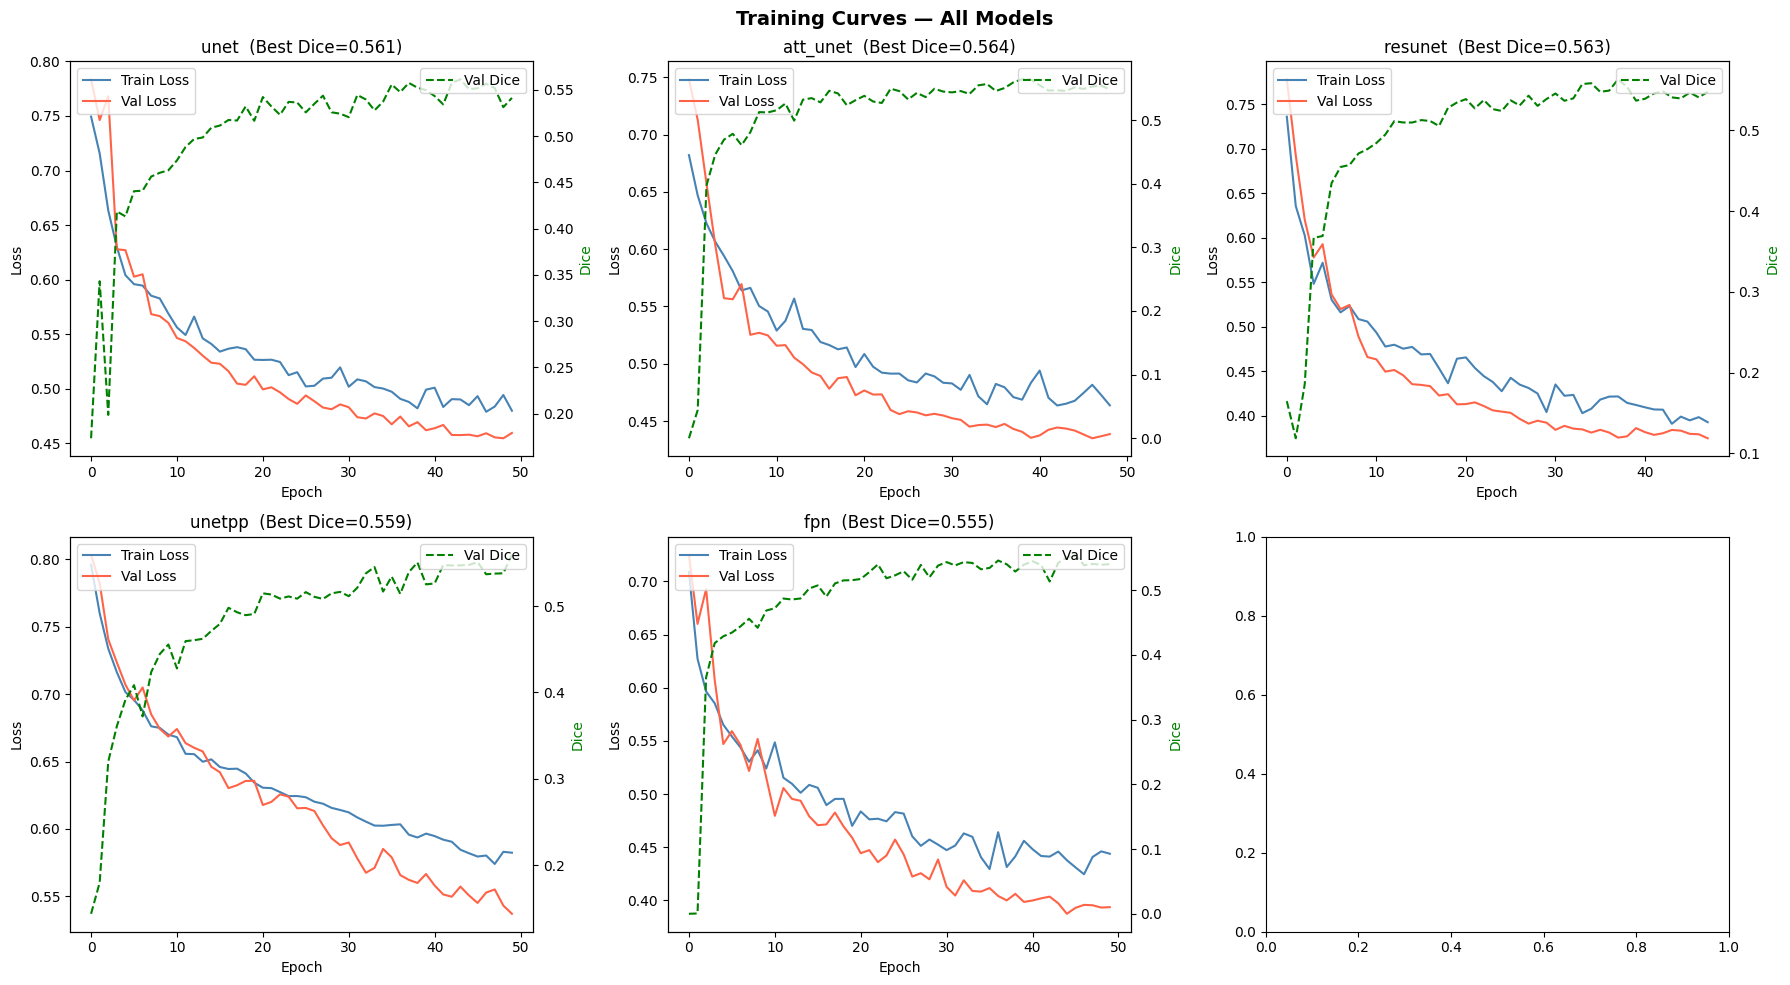

[SAVED] training_curves.png


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (mname, res) in zip(axes, all_results.items()):
    h = res['history']
    ax.plot(h['train_loss'], label='Train Loss', color='steelblue')
    ax.plot(h['val_loss'],   label='Val Loss',   color='tomato')
    ax2 = ax.twinx()
    ax2.plot(h['val_dice'], label='Val Dice', color='green', linestyle='--')
    ax2.set_ylabel('Dice', color='green')
    ax.set_title(f"{mname}  (Best Dice={res['best_dice']:.3f})")
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.suptitle('Training Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,'training_curves.png'), dpi=120); plt.show()
print(f"[SAVED] training_curves.png")

## Section 7 — Evaluation

In [19]:
def evaluate_model(model, loader, model_name='model'):
    model.eval()
    per_image = []
    all_pred, all_gt = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            for i in range(imgs.size(0)):
                m = batch_metrics(preds[i:i+1], masks[i:i+1])
                per_image.append(m)
                pred_bin = (preds[i:i+1] > 0.5).long().cpu().numpy().flatten()
                gt_bin   = masks[i:i+1].long().cpu().numpy().flatten()
                all_pred.extend(pred_bin.tolist())
                all_gt.extend(gt_bin.tolist())
    # Per-image Dice
    dices = [m['dice'] for m in per_image]
    print(f"\n[EVAL] {model_name}")
    print(f"  Per-image Dice: {[f'{d:.3f}' for d in dices]}")
    blank = [d for d in dices if d < 0.1]
    if blank: print(f"  ⚠️  {len(blank)} BLANK predictions detected (Dice<0.1)!")
    # Summary
    print(f"  {'Metric':12s}  {'Mean':>8}  {'Std':>8}")
    print("  " + "-"*32)
    for key in ['dice','iou','precision','recall']:
        vals = [m[key] for m in per_image]
        print(f"  {key:12s}  {np.mean(vals):>8.4f}  {np.std(vals):>8.4f}")
    # Confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(all_gt, all_pred)
    print(f"\n  Confusion Matrix:\n{cm}")
    return per_image

# Evaluate best model
top_model_name = max(all_results, key=lambda k: all_results[k]['best_dice'])
print(f"[TOP MODEL] {top_model_name}  (Dice={all_results[top_model_name]['best_dice']:.4f})")

eval_results = {}
for mname, model in trained_models.items():
    eval_results[mname] = evaluate_model(model, val_loader, mname)

[TOP MODEL] att_unet  (Dice=0.5640)

[EVAL] unet
  Per-image Dice: ['0.545', '0.558', '0.552', '0.616', '0.488', '0.596', '0.550', '0.539', '0.507']
  Metric            Mean       Std
  --------------------------------
  dice            0.5502    0.0371
  iou             0.3804    0.0355
  precision       0.5074    0.0404
  recall          0.6040    0.0521

  Confusion Matrix:
[[515837  27110]
 [ 18561  28316]]

[EVAL] att_unet
  Per-image Dice: ['0.563', '0.575', '0.563', '0.630', '0.497', '0.606', '0.572', '0.554', '0.500']
  Metric            Mean       Std
  --------------------------------
  dice            0.5622    0.0407
  iou             0.3921    0.0392
  precision       0.5701    0.0406
  recall          0.5571    0.0542

  Confusion Matrix:
[[523585  19362]
 [ 20737  26140]]

[EVAL] resunet
  Per-image Dice: ['0.564', '0.573', '0.562', '0.622', '0.493', '0.597', '0.572', '0.548', '0.505']
  Metric            Mean       Std
  --------------------------------
  dice          

## Section 8 — Inference, Ensemble & Visualization

[ENSEMBLE] Top-2 models: ['att_unet', 'resunet']
[PRED STATS] Max prob range: 0.993 – 0.997
✅ Predictions not collapsed to zero


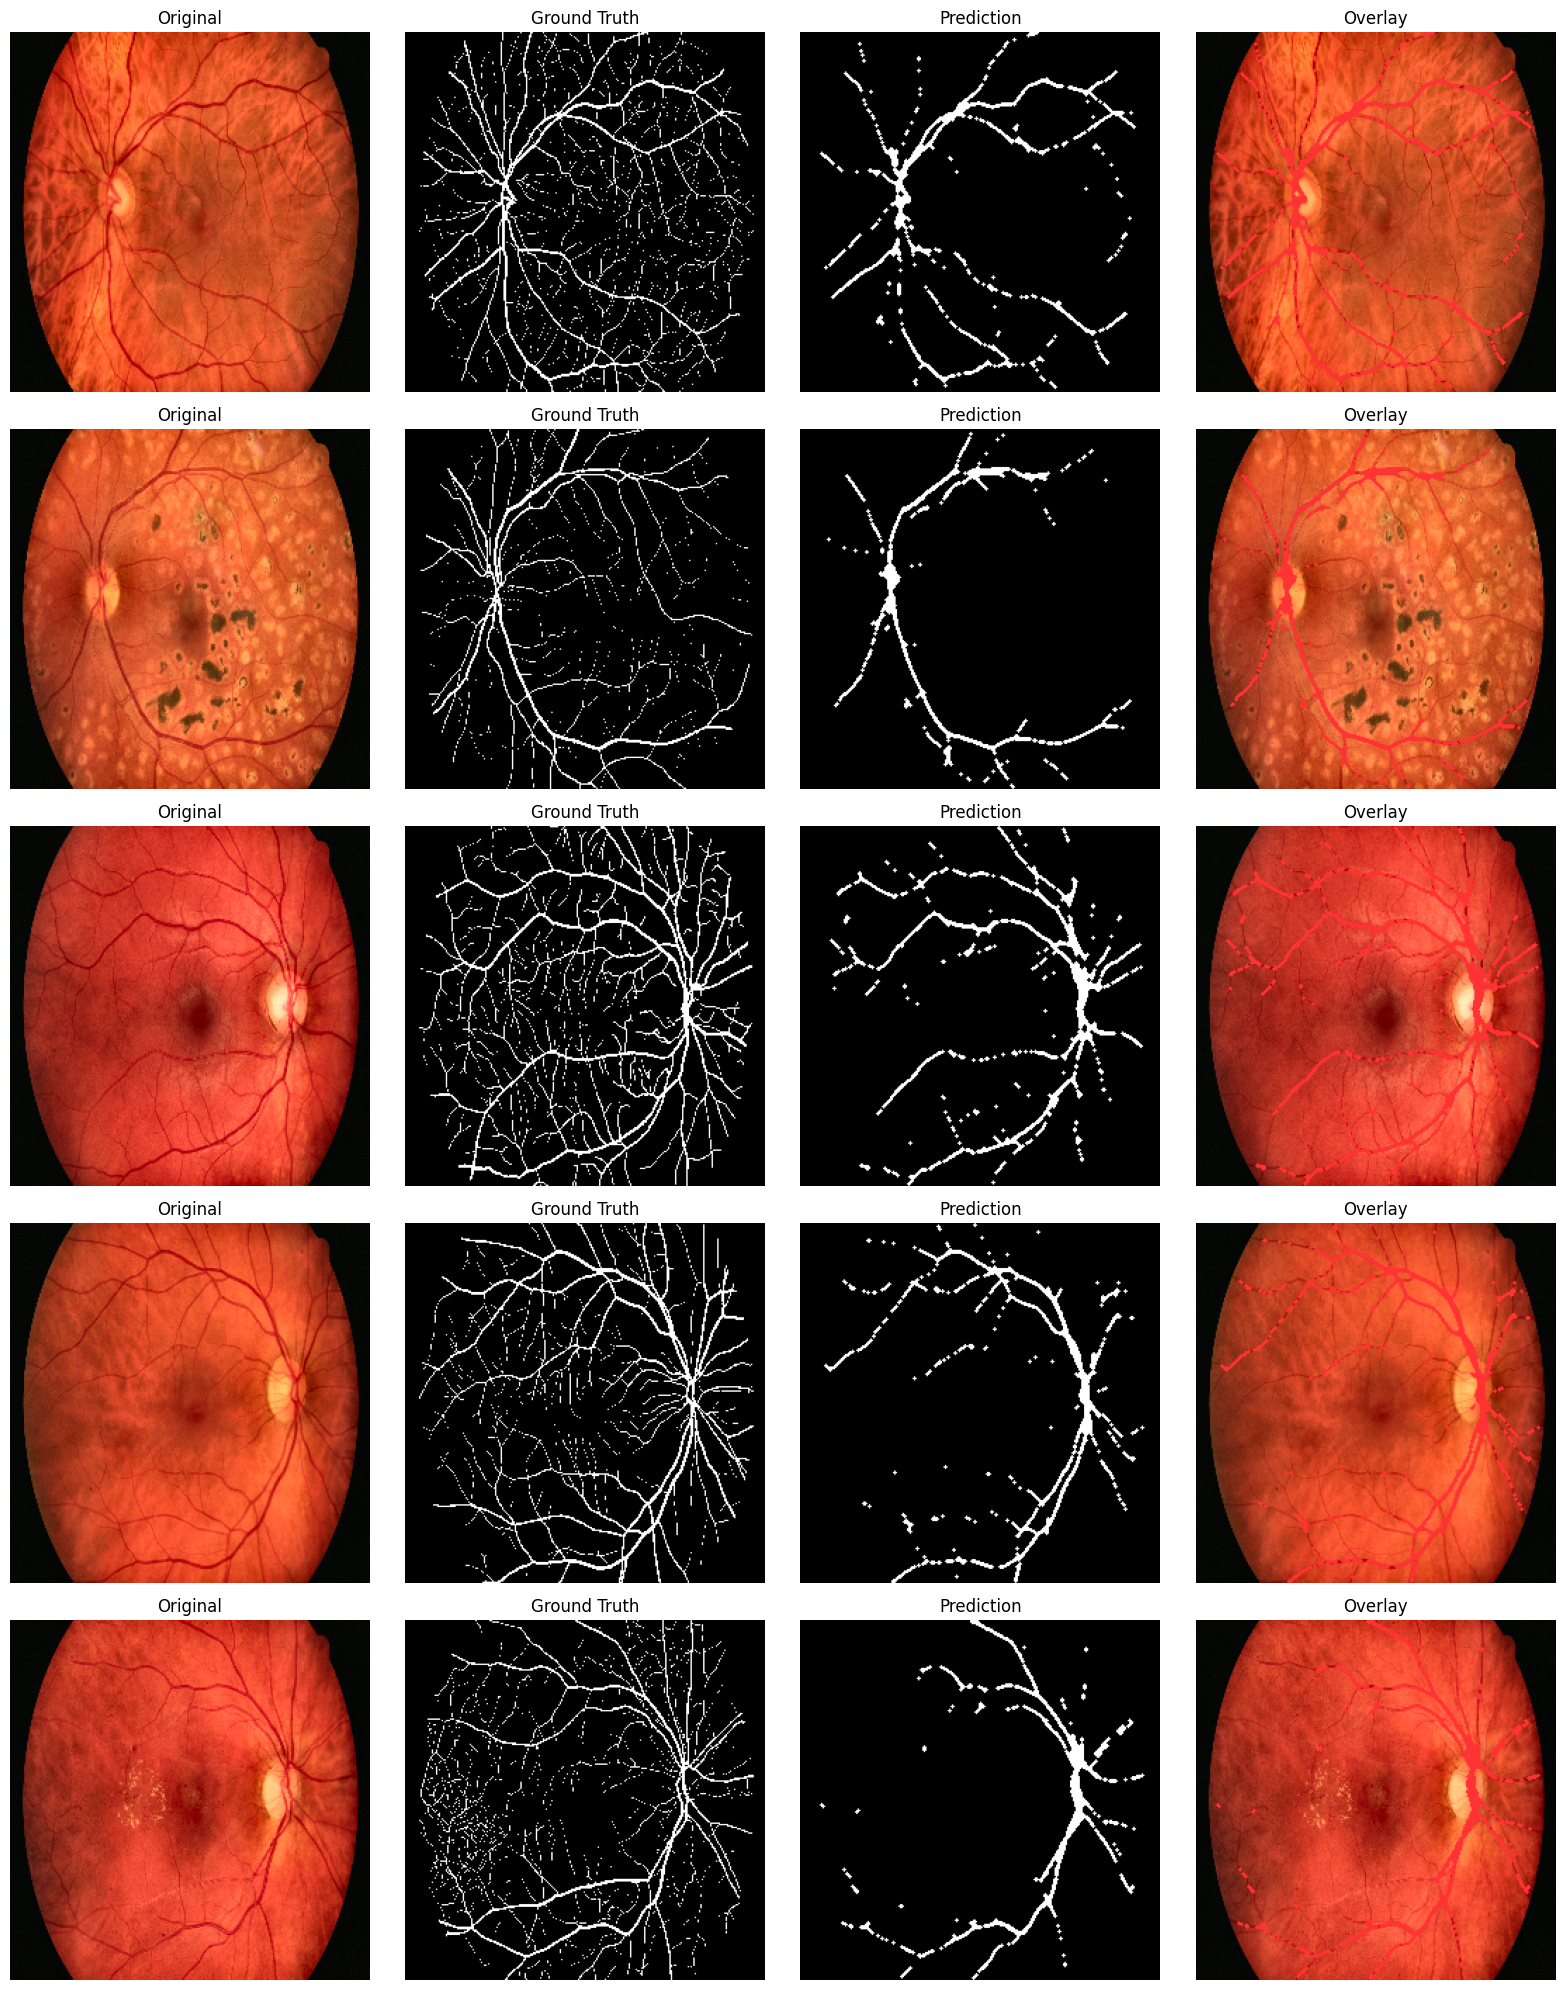

[VIZ] Saved: c:\ACV\acv project\results\predictions_grid.png


In [20]:
# ── Pick top-2 models for ensemble ────────────────────────
top2 = sorted(all_results, key=lambda k: all_results[k]['best_dice'], reverse=True)[:2]
print(f"[ENSEMBLE] Top-2 models: {top2}")
ensemble_models = [trained_models[m] for m in top2]

# ── Inference on val set: TTA + Ensemble + Morphology ─────
all_imgs=[]; all_gts=[]; all_preds=[]
for imgs, masks in val_loader:
    for i in range(imgs.size(0)):
        img_t = imgs[i:i+1]
        pred  = ensemble_predict(ensemble_models, img_t, DEVICE)
        pred_np = pred.squeeze().numpy()
        pred_np = (pred_np > 0.5).astype(np.uint8)
        pred_np = morph_postprocess(pred_np)
        pred_t  = torch.from_numpy(pred_np.astype(np.float32)).unsqueeze(0).unsqueeze(0)
        all_imgs.append(imgs[i]); all_gts.append(masks[i]); all_preds.append(pred_t.squeeze(0))

# De-normalize images for display
mean_t = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std_t  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
disp_imgs = [img * std_t + mean_t for img in all_imgs]

# ── Pred probability stats ─────────────────────────────────
raw_preds = []
with torch.no_grad():
    for imgs, _ in val_loader:
        raw = ensemble_predict(ensemble_models, imgs[0:1], DEVICE)
        raw_preds.append(raw.max().item())
print(f"[PRED STATS] Max prob range: {min(raw_preds):.3f} – {max(raw_preds):.3f}")
if max(raw_preds) < 0.1:
    print("⚠️  WARNING: All predictions near zero!")
else:
    print("✅ Predictions not collapsed to zero")

# ── Visualize 5 predictions ───────────────────────────────
save_p = os.path.join(RESULTS_DIR, 'predictions_grid.png')
visualize_predictions(disp_imgs, all_gts, all_preds, n=5, save_path=save_p)

## Final Summary

In [21]:
print("\n" + "="*60)
print("       RETINAL VESSEL SEGMENTATION — FINAL RESULTS")
print("="*60)
print(f"  Dataset        : {len(img_paths)} paired images (train={len(train_ds)}/val={len(val_ds)})")
print(f"  Image size     : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Best loss fn   : {best_loss_name}")
print(f"  Ensemble       : {top2}")
print()
print(f"  {'Model':15s}  {'Best Dice':>10}")
print("  " + "-"*30)
for mname, res in sorted(all_results.items(), key=lambda x: -x[1]['best_dice']):
    tag = " ← BEST" if mname == top_model_name else ""
    print(f"  {mname:15s}  {res['best_dice']:>10.4f}{tag}")
print("="*60)
print(f"  Checkpoints : {CKPT_DIR}")
print(f"  Results     : {RESULTS_DIR}")
print("="*60)


       RETINAL VESSEL SEGMENTATION — FINAL RESULTS
  Dataset        : 45 paired images (train=36/val=9)
  Image size     : 256x256
  Best loss fn   : BCE+Dice
  Ensemble       : ['att_unet', 'resunet']

  Model             Best Dice
  ------------------------------
  att_unet             0.5640 ← BEST
  resunet              0.5631
  unet                 0.5613
  unetpp               0.5594
  fpn                  0.5548
  Checkpoints : c:\ACV\acv project\checkpoints
  Results     : c:\ACV\acv project\results
